# Retail Sales Analytics — Python Data Analysis

**Project:** Retail Sales Analytics  
**Tool:** Python — Google Colab  
**Dataset:** Retail Sales Cleaned  
**Records:** 1,000 rows × 20 columns

## Objectives
- Data loading and validation
- Exploratory Data Analysis (EDA)
- Sales and profit analysis
- Category and regional analysis
- Product and customer analysis
- Data visualization
- Business insights

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Locate the Dataset

In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'retail_sales_cleaned.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/python for data analyst/Retail_Sales_Analytics_Python./retail_sales_cleaned.csv


## 4. Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/python for data analyst/Retail_Sales_Analytics_Python./retail_sales_cleaned.csv')

df.head()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Gender,Age,City,State,Region,Product_ID,Product_Name,Category,Sub_Category,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method
0,ORD00001,2025-03-19,2025-03-20,C0043,Priya,Male,28,Delhi,Delhi,North,P003,Jeans,Clothing,Jeans,6,2495,0.10,13473.0,2155.63,Cash
1,ORD00002,2025-09-02,2025-09-05,C0044,Rahul,Female,57,Bengaluru,Karnataka,South,P029,Laptop,Electronics,Laptop,6,2267,0.10,12241.8,1361.74,Cash
2,ORD00003,2025-01-04,2025-01-07,C0103,Sneha,Male,58,Chennai,Tamil Nadu,South,P041,Desk,Furniture,Desk,8,3488,0.05,26508.8,5687.94,UPI
3,ORD00004,2025-07-06,2025-07-08,C0054,Priya,Male,51,Bengaluru,Karnataka,South,P024,Laptop,Electronics,Laptop,8,1680,0.00,13440.0,2696.57,Cash
4,ORD00005,2025-07-29,2025-08-05,C0215,Aarav,Male,47,Bengaluru,Karnataka,South,P045,Phone,Electronics,Phone,5,4807,0.00,24035.0,4827.00,UPI


## 5. Initial Data Inspection

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (1000, 20)

Columns:
['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID', 'Customer_Name', 'Gender', 'Age', 'City', 'State', 'Region', 'Product_ID', 'Product_Name', 'Category', 'Sub_Category', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method']

Data Types:
Order_ID           object
Order_Date         object
Ship_Date          object
Customer_ID        object
Customer_Name      object
Gender             object
Age                 int64
City               object
State              object
Region             object
Product_ID         object
Product_Name       object
Category           object
Sub_Category       object
Quantity            int64
Unit_Price          int64
Discount          float64
Sales             float64
Profit            float64
Payment_Method     object
dtype: object

Missing Values:
Order_ID          0
Order_Date        0
Ship_Date         0
Customer_ID       0
Customer_Name     0
Gender            0
Age               0
City              0

## 6. Data Cleaning and Validation

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

print(df[['Order_Date', 'Ship_Date']].dtypes)

Order_Date    datetime64[ns]
Ship_Date     datetime64[ns]
dtype: object


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

print(df[['Order_Date', 'Ship_Date']].dtypes)

Order_Date    datetime64[ns]
Ship_Date     datetime64[ns]
dtype: object


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


#Descriptive Statistics

In [ ]:
df.describe()

,Order_Date,Ship_Date,Age,Quantity,Unit_Price,Discount,Sales,Profit
count,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,2025-06-30 18:40:19.200000256,2025-07-04 19:45:07.200000,41.618000,4.553000,2539.220000,0.074900,10948.18885,1649.615970
min,2025-01-01 00:00:00,2025-01-02 00:00:00,18.000000,1.000000,104.000000,0.000000,113.90000,10.810000
25%,2025-03-29 18:00:00,2025-04-03 00:00:00,29.000000,2.000000,1312.250000,0.000000,3304.52500,433.915000
50%,2025-07-01 00:00:00,2025-07-05 12:00:00,42.000000,5.000000,2570.500000,0.100000,8551.65000,1133.845000
75%,2025-09-27 06:00:00,2025-09-29 06:00:00,54.000000,7.000000,3740.000000,0.100000,16364.40000,2284.895000
max,2025-12-31 00:00:00,2026-01-07 00:00:00,65.000000,8.000000,4996.000000,0.150000,38544.00000,9568.070000
std,NaN,NaN,13.902999,2.359398,1415.044157,0.055974,8953.43300,1625.575015


# Categorical Data Analysis

In [ ]:
print("Categories:")
print(df['Category'].value_counts())

print("\nRegions:")
print(df['Region'].value_counts())

print("\nPayment Methods:")
print(df['Payment_Method'].value_counts())

Categories:
Category
Furniture      266
Electronics    247
Clothing       246
Grocery        241
Name: count, dtype: int64

Regions:
Region
South    662
North    176
West     162
Name: count, dtype: int64

Payment Methods:
Payment_Method
Cash    357
UPI     330
Card    313
Name: count, dtype: int64


#Sales and Profit Analysis

In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
average_sales = df['Sales'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)
print("Average Sales:", average_sales)

Total Sales: 10948188.850000001
Total Profit: 1649615.9700000002
Total Quantity Sold: 4553
Average Sales: 10948.188850000002


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Furniture      2830331.55
Clothing       2733070.15
Grocery        2703264.90
Electronics    2681522.25
Name: Sales, dtype: float64


In [ ]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(category_profit)

Category
Furniture      426280.74
Clothing       413815.98
Grocery        407708.06
Electronics    401811.19
Name: Profit, dtype: float64


In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
South    7281589.60
North    1963097.40
West     1703501.85
Name: Sales, dtype: float64


In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print(region_profit)

Region
South    1103386.25
North     288932.94
West      257296.78
Name: Profit, dtype: float64


#Top Products and Customers Analysis

In [ ]:
top_products = (
    df.groupby('Product_Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product_Name
Jeans     2733070.15
Desk      1449617.25
Rice      1445590.80
Laptop    1381008.90
Chair     1380714.30
Phone     1300513.35
Tea       1257674.10
Name: Sales, dtype: float64


In [ ]:
top_customers = (
    df.groupby('Customer_Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer_Name
Priya               2414281.45
Aarav               2350994.25
Rahul               2303339.60
Diya                2013565.40
Sneha               1722460.35
Unknown Customer     143547.80
Name: Sales, dtype: float64


#Monthly Sales and Profit Analysis

In [ ]:
df['Month'] = df['Order_Date'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

print(monthly_sales)

Month
2025-01    1101292.30
2025-02     851791.60
2025-03    1085162.95
2025-04     810584.80
2025-05     860286.80
2025-06     861435.85
2025-07     740207.75
2025-08    1023670.25
2025-09    1070167.45
2025-10     714642.40
2025-11     923236.60
2025-12     905710.10
Freq: M, Name: Sales, dtype: float64


In [ ]:
monthly_profit = (
    df.groupby('Month')['Profit']
    .sum()
)

print(monthly_profit)

Month
2025-01    161781.25
2025-02    121747.12
2025-03    168567.13
2025-04    139758.49
2025-05    135582.49
2025-06    133052.72
2025-07    104004.67
2025-08    156765.60
2025-09    154636.77
2025-10    112325.08
2025-11    124550.13
2025-12    136844.52
Freq: M, Name: Profit, dtype: float64


#Data Visualization

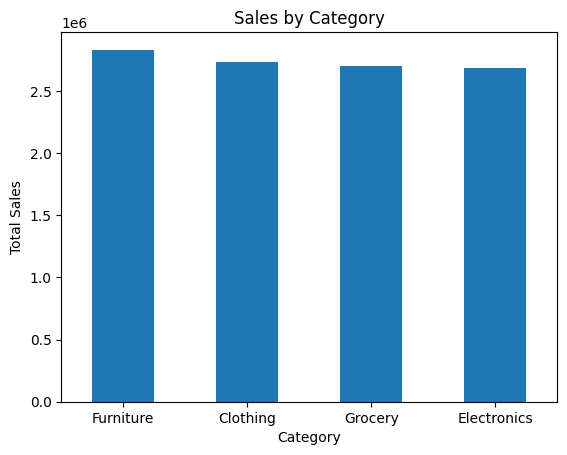

In [ ]:
category_sales.plot(kind='bar', title='Sales by Category')

plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

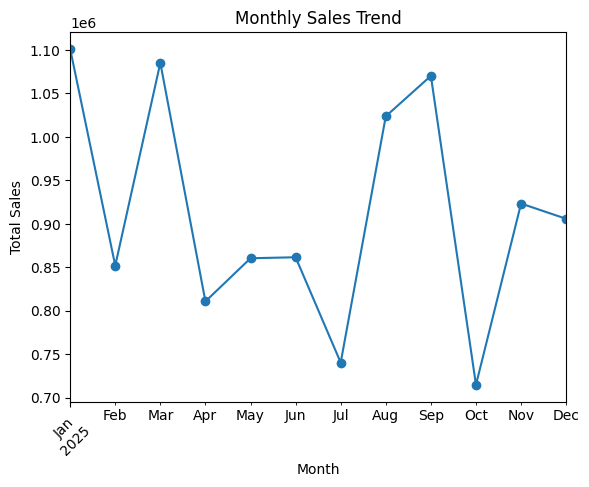

In [ ]:
monthly_sales.plot(kind='line', marker='o', title='Monthly Sales Trend')

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

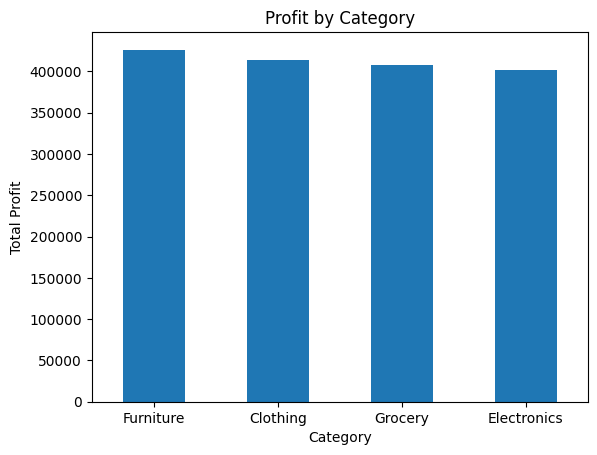

In [ ]:
category_profit.plot(kind='bar', title='Profit by Category')

plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.show()

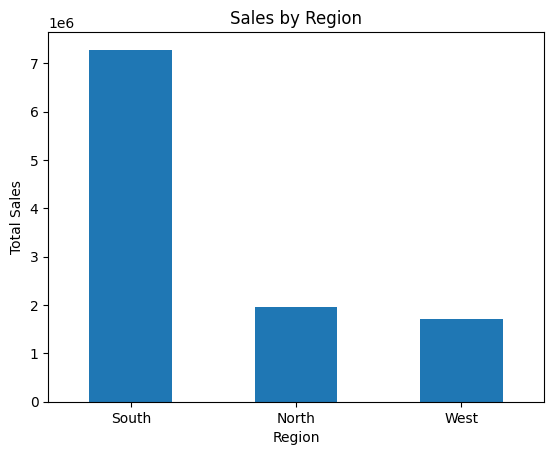

In [ ]:
region_sales.plot(kind='bar', title='Sales by Region')

plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

#Correlation Analysis

In [ ]:
correlation = df[['Age', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit']].corr()

print(correlation)

                 Age  Quantity  Unit_Price  Discount     Sales    Profit
Age         1.000000 -0.033163    0.026796  0.059827 -0.023462 -0.034824
Quantity   -0.033163  1.000000    0.054037 -0.030468  0.650711  0.553642
Unit_Price  0.026796  0.054037    1.000000  0.012804  0.700065  0.599149
Discount    0.059827 -0.030468    0.012804  1.000000 -0.096293 -0.083793
Sales      -0.023462  0.650711    0.700065 -0.096293  1.000000  0.862063
Profit     -0.034824  0.553642    0.599149 -0.083793  0.862063  1.000000


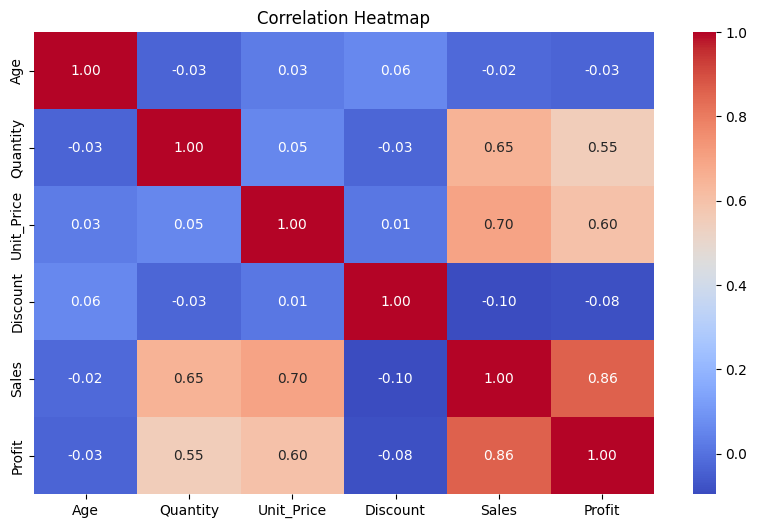

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

#Payment and Gender Analysis


In [ ]:
payment_analysis = (
    df.groupby('Payment_Method')
    .agg(
        Orders=('Order_ID', 'nunique'),
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
    .sort_values('Sales', ascending=False)
)

print(payment_analysis)

                Orders       Sales     Profit
Payment_Method                               
Cash               357  3917061.10  574309.43
UPI                330  3628372.45  551187.38
Card               313  3402755.30  524119.16


In [ ]:
gender_analysis = (
    df.groupby('Gender')
    .agg(
        Orders=('Order_ID', 'nunique'),
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
    .sort_values('Sales', ascending=False)
)

print(gender_analysis)

        Orders       Sales     Profit
Gender                               
Male       498  5474240.55  828624.96
Female     502  5473948.30  820991.01


#Key Business Insights

In [ ]:
print("===== KEY BUSINESS INSIGHTS =====")

print("\nBest Selling Category:")
print(category_sales.idxmax(), "→", category_sales.max())

print("\nMost Profitable Category:")
print(category_profit.idxmax(), "→", category_profit.max())

print("\nBest Performing Region:")
print(region_sales.idxmax(), "→", region_sales.max())

print("\nTop Product:")
print(top_products.index[0], "→", top_products.iloc[0])

print("\nTop Customer:")
print(top_customers.index[0], "→", top_customers.iloc[0])

print("\nBest Payment Method by Sales:")
print(payment_analysis['Sales'].idxmax(), "→", payment_analysis['Sales'].max())

===== KEY BUSINESS INSIGHTS =====

Best Selling Category:
Furniture → 2830331.55

Most Profitable Category:
Furniture → 426280.74

Best Performing Region:
South → 7281589.6

Top Product:
Jeans → 2733070.15

Top Customer:
Priya → 2414281.45

Best Payment Method by Sales:
Cash → 3917061.1


#Retail Sales Analytics Summary

In [ ]:
print("===== RETAIL SALES ANALYTICS SUMMARY =====")

print("Total Orders:", df['Order_ID'].nunique())
print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Total Quantity Sold:", df['Quantity'].sum())
print("Average Sales per Order:", df['Sales'].mean())
print("Average Profit per Order:", df['Profit'].mean())
print("Date Range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())

===== RETAIL SALES ANALYTICS SUMMARY =====
Total Orders: 1000
Total Sales: 10948188.850000001
Total Profit: 1649615.9700000002
Total Quantity Sold: 4553
Average Sales per Order: 10948.188850000002
Average Profit per Order: 1649.6159700000003
Date Range: 2025-01-01 to 2025-12-31
